In [1]:
# Setting up the file path
import sys
import os
parent_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.append(parent_dir)

In [2]:
# Import Packages
from Index_Generators.FFNN import FFNN
import torch
import torch.nn as nn
from torchviz import make_dot
from IPython.display import display
from torchinfo import summary
import netron

In [3]:
# Create a Feed Forward Neural Network
MyFFNN = FFNN(input_size=2, output_size=3, hidden_size=5, num_layers=2)

In [4]:
# Print the model
print(MyFFNN)

FFNN(
  (model): Sequential(
    (0): Linear(in_features=2, out_features=5, bias=True)
    (1): ReLU()
    (2): Sequential(
      (0): Linear(in_features=5, out_features=5, bias=True)
      (1): Tanh()
    )
    (3): Sequential(
      (0): Linear(in_features=5, out_features=5, bias=True)
      (1): Tanh()
    )
    (4): Linear(in_features=5, out_features=3, bias=True)
  )
)


Input: tensor([[-1.4594, -0.7337]])
Output: tensor([[-0.0065, -0.5001, -0.3162]], grad_fn=<AddmmBackward0>)


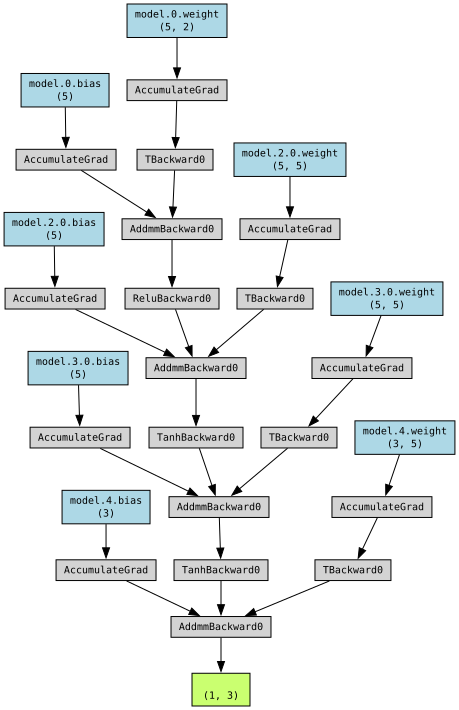

In [5]:
# Visualize the computation graph
dummy_input = torch.randn(1, 2)  # Batch size = 1, Input size = 2
output = MyFFNN(dummy_input)
print('Input:', dummy_input)
print('Output:', output)
dot = make_dot(output, params=dict(MyFFNN.named_parameters()))
display(dot)

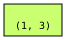

In [6]:
# Visualize the detached computation graph
dot = make_dot(output.detach(), params=dict(MyFFNN.named_parameters()))
display(dot)

In [ ]:
# Print Model Summary
summary(MyFFNN, input_size=(1, 2))  # Batch size = 1, Input size = 10

Layer (type:depth-idx)                   Output Shape              Param #
FFNN                                     [1, 3]                    --
├─Sequential: 1-1                        [1, 3]                    --
│    └─Linear: 2-1                       [1, 5]                    15
│    └─ReLU: 2-2                         [1, 5]                    --
│    └─Sequential: 2-3                   [1, 5]                    --
│    │    └─Linear: 3-1                  [1, 5]                    30
│    │    └─Tanh: 3-2                    [1, 5]                    --
│    └─Sequential: 2-4                   [1, 5]                    --
│    │    └─Linear: 3-3                  [1, 5]                    30
│    │    └─Tanh: 3-4                    [1, 5]                    --
│    └─Linear: 2-5                       [1, 3]                    18
Total params: 93
Trainable params: 93
Non-trainable params: 0
Total mult-adds (M): 0.00
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params 

In [8]:
# Visualize in Netron
torch.onnx.export(MyFFNN, dummy_input, "ffnn.onnx")
netron.start("ffnn.onnx")

Serving 'ffnn.onnx' at http://localhost:8080


('localhost', 8080)